In [1]:
import pandas as pd

In [3]:
df_amount = pd.read_csv("./data/data-drep-amount-26.8.25.csv")
df_delegetions = pd.read_csv("./data/data-drep-delegetions-26.8.25.csv")

#print column names
print(df_amount.columns)
print(df_delegetions.columns)


Index(['distr_id', 'amount', 'epoch_no', 'active_until', 'drep_id', 'raw',
       'view', 'has_script'],
      dtype='object')
Index(['epoch_no', 'tx_hash', 'cert_index', 'delegator_stake_address',
       'drep_view'],
      dtype='object')


In [7]:
import pandas as pd
from itertools import product

# Load your data
df_amount = pd.read_csv("./data/data-drep-amount-26.8.25.csv")        # for DRep list / epoch range
df_deleg  = pd.read_csv("./data/data-drep-delegetions-26.8.25.csv")

# Canonical epoch list & DRep universe
epochs = sorted(df_amount["epoch_no"].unique())
dreps  = sorted(set(df_amount["view"].unique()).union(df_deleg["drep_view"].unique()))

# --- 1) Reduce to the *last* delegation per (delegator, epoch) ---
# Sort by delegator, epoch, cert_index to get the final action within the epoch
df_deleg_sorted = df_deleg.sort_values(["delegator_stake_address","epoch_no","cert_index"])
last_in_epoch = (
    df_deleg_sorted
    .groupby(["delegator_stake_address","epoch_no"], as_index=False)
    .tail(1)
    .sort_values(["delegator_stake_address","epoch_no"])  # ensure stable order for shift()
)

# --- 2) Mark only *changes* (including first-ever) as "new delegations" ---
last_in_epoch["prev_drep_view"] = (
    last_in_epoch.groupby("delegator_stake_address")["drep_view"].shift()
)
is_new = last_in_epoch["drep_view"] != last_in_epoch["prev_drep_view"]
new_events = last_in_epoch[is_new].copy()

# Optional: keep only epochs present in df_amount (safe)
new_events = new_events[new_events["epoch_no"].isin(epochs)]

# --- 3) Count NEW delegators per (epoch, drep) ---
new_counts = (
    new_events
    .groupby(["epoch_no","drep_view"], as_index=False)
    .agg(new_delegators=("delegator_stake_address","nunique"))
)

# --- 4) Ensure a complete (epoch, drep) grid and fill missing with 0 ---
grid = pd.DataFrame(list(product(epochs, dreps)), columns=["epoch_no","drep_view"])
new_counts_full = grid.merge(new_counts, on=["epoch_no","drep_view"], how="left")
new_counts_full["new_delegators"] = new_counts_full["new_delegators"].fillna(0).astype(int)

# --- 5) Add the 2-epoch lag (when it becomes effective on-chain) ---
new_counts_full = (
    new_counts_full
    .sort_values(["drep_view","epoch_no"])
    .assign(new_delegators_lag2=lambda d: d.groupby("drep_view")["new_delegators"].shift(2).fillna(0).astype(int))
)

# --- 6) Save tidy CSV ---
out_path = "./data/drep_new_delegations_per_epoch.csv"
new_counts_full.to_csv(out_path, index=False)

print(f"✅ Wrote {len(new_counts_full):,} rows to {out_path}")
print(new_counts_full.head(10).to_string(index=False))


✅ Wrote 100,110 rows to ./data/drep_new_delegations_per_epoch.csv
 epoch_no                                                drep_view  new_delegators  new_delegators_lag2
      508 drep1000002hneyj7jl9y95m0zxdsg6dp9n9y59lvlm7xjqp4qh2jx7h               0                    0
      509 drep1000002hneyj7jl9y95m0zxdsg6dp9n9y59lvlm7xjqp4qh2jx7h               0                    0
      510 drep1000002hneyj7jl9y95m0zxdsg6dp9n9y59lvlm7xjqp4qh2jx7h               0                    0
      511 drep1000002hneyj7jl9y95m0zxdsg6dp9n9y59lvlm7xjqp4qh2jx7h               0                    0
      512 drep1000002hneyj7jl9y95m0zxdsg6dp9n9y59lvlm7xjqp4qh2jx7h               0                    0
      513 drep1000002hneyj7jl9y95m0zxdsg6dp9n9y59lvlm7xjqp4qh2jx7h               0                    0
      514 drep1000002hneyj7jl9y95m0zxdsg6dp9n9y59lvlm7xjqp4qh2jx7h               0                    0
      515 drep1000002hneyj7jl9y95m0zxdsg6dp9n9y59lvlm7xjqp4qh2jx7h               0                    

In [10]:
import pandas as pd
from itertools import product

# Load your files
df_amount = pd.read_csv("./data/data-drep-amount-26.8.25.csv")        # has: epoch_no, amount, view (= drep)
df_deleg  = pd.read_csv("./data/data-drep-delegetions-26.8.25.csv")   # has: epoch_no, delegator_stake_address, drep_view, cert_index, ...

# Canonical sets
epochs = sorted(df_amount["epoch_no"].unique())
dreps  = sorted(set(df_amount["view"].unique()).union(df_deleg["drep_view"].unique()))

# --- 1) For each (delegator, epoch) keep the *last* delegation in that epoch ---
df_deleg_sorted = df_deleg.sort_values(["delegator_stake_address", "epoch_no", "cert_index"])
last_in_epoch = (
    df_deleg_sorted
    .groupby(["delegator_stake_address", "epoch_no"], as_index=False)
    .tail(1)
    .sort_values(["delegator_stake_address", "epoch_no"])
)

# --- 2) Mark NEW delegations (including first-ever) by comparing to the previous epoch's final drep per delegator ---
last_in_epoch["prev_drep_view"] = last_in_epoch.groupby("delegator_stake_address")["drep_view"].shift()
is_new = last_in_epoch["drep_view"] != last_in_epoch["prev_drep_view"]
new_events = last_in_epoch[is_new].copy()

# Keep only epochs present in df_amount (optional but tidy)
new_events = new_events[new_events["epoch_no"].isin(epochs)]

# --- 3) Count NEW delegators per (epoch, drep) ---
new_counts = (
    new_events
    .groupby(["epoch_no", "drep_view"], as_index=False)
    .agg(new_delegators=("delegator_stake_address", "nunique"))
)

# --- 4) Complete grid & fill zeros ---
grid = pd.DataFrame(list(product(epochs, dreps)), columns=["epoch_no", "drep_view"])
new_counts_full = grid.merge(new_counts, on=["epoch_no", "drep_view"], how="left")
new_counts_full["new_delegators"] = new_counts_full["new_delegators"].fillna(0).astype(int)

# --- 5) Add 2-epoch lag (when it becomes effective in snapshots) ---
new_counts_full = (
    new_counts_full
    .sort_values(["drep_view", "epoch_no"])
    .assign(new_delegators_lag2=lambda d: d.groupby("drep_view")["new_delegators"].shift(2).fillna(0).astype(int))
)

# --- 6) Bring in AMOUNT per epoch (snapshot power) from df_amount ---
# df_amount uses 'view' for the DRep label
amount_tbl = (
    df_amount[["epoch_no", "view", "amount"]]
    .rename(columns={"view": "drep_view", "amount": "voting_power_lovelace"})
)

# Merge counts with amount
result = (
    new_counts_full
    .merge(amount_tbl, on=["epoch_no", "drep_view"], how="left")
    .sort_values(["epoch_no", "drep_view"])
)

# Optional: if you want an “amount aligned to lag2” view for easy comparison, you can also add:
# result["voting_power_lovelace_fwd2"] = result.groupby("drep_view")["voting_power_lovelace"].shift(-2)

# Save
out_path = "./data/drep_new_delegations_and_amount_per_epoch.csv"
result.to_csv(out_path, index=False)

print(f"✅ Wrote {len(result):,} rows to {out_path}")
print(result.head(12).to_string(index=False))


✅ Wrote 100,110 rows to ./data/drep_new_delegations_and_amount_per_epoch.csv
 epoch_no                                                drep_view  new_delegators  new_delegators_lag2  voting_power_lovelace
      508 drep1000002hneyj7jl9y95m0zxdsg6dp9n9y59lvlm7xjqp4qh2jx7h               0                    0                    NaN
      508 drep100gzgh095hxsgarhdvacsz8m98sdwkyhm5924w74au5djs8u5ud               0                    0                    NaN
      508 drep100jz6lkn22jl85gj29vtlwwdrdttmxr8dul6peywguy7waev0hz               0                    0                    NaN
      508 drep100pnfhkx8ughe8ra3vamdhanqhmsc8dl0cgszh3ffd5e75vpgy2               0                    0                    NaN
      508 drep1025p6hdcn0rf9lqdy39fnsjcw6qg2p4hhwmx65xc63352p5r0gn               0                    0                    NaN
      508 drep1029z4azgy00vflahgxrl57hyl3tegdfg0f4mwf3aaw8pvj6yvz7               0                    0                    NaN
      508 drep102fvfd8peu4z8scaddk

<bound method NDFrame.tail of         epoch_no                                          drep_view  \
0            508  drep1000002hneyj7jl9y95m0zxdsg6dp9n9y59lvlm7xj...   
71           508  drep100gzgh095hxsgarhdvacsz8m98sdwkyhm5924w74a...   
142          508  drep100jz6lkn22jl85gj29vtlwwdrdttmxr8dul6peywg...   
213          508  drep100pnfhkx8ughe8ra3vamdhanqhmsc8dl0cgszh3ff...   
284          508  drep1025p6hdcn0rf9lqdy39fnsjcw6qg2p4hhwmx65xc6...   
...          ...                                                ...   
99825        578  drep1zyhez9l3r4fyl8plfg83ugqwmgvsuffx0vj2ry5lh...   
99896        578  drep1zyv6xda3yqfuedw7l40tp6trxk7l2xpfa8wt8nkzw...   
99967        578  drep1zzuasedw4v7ctfdfvrsmr6surqxh78fuakxvdnztu...   
100038       578                                drep_always_abstain   
100109       578                          drep_always_no_confidence   

        new_delegators  new_delegators_lag2  voting_power_lovelace  
0                    0                    0     

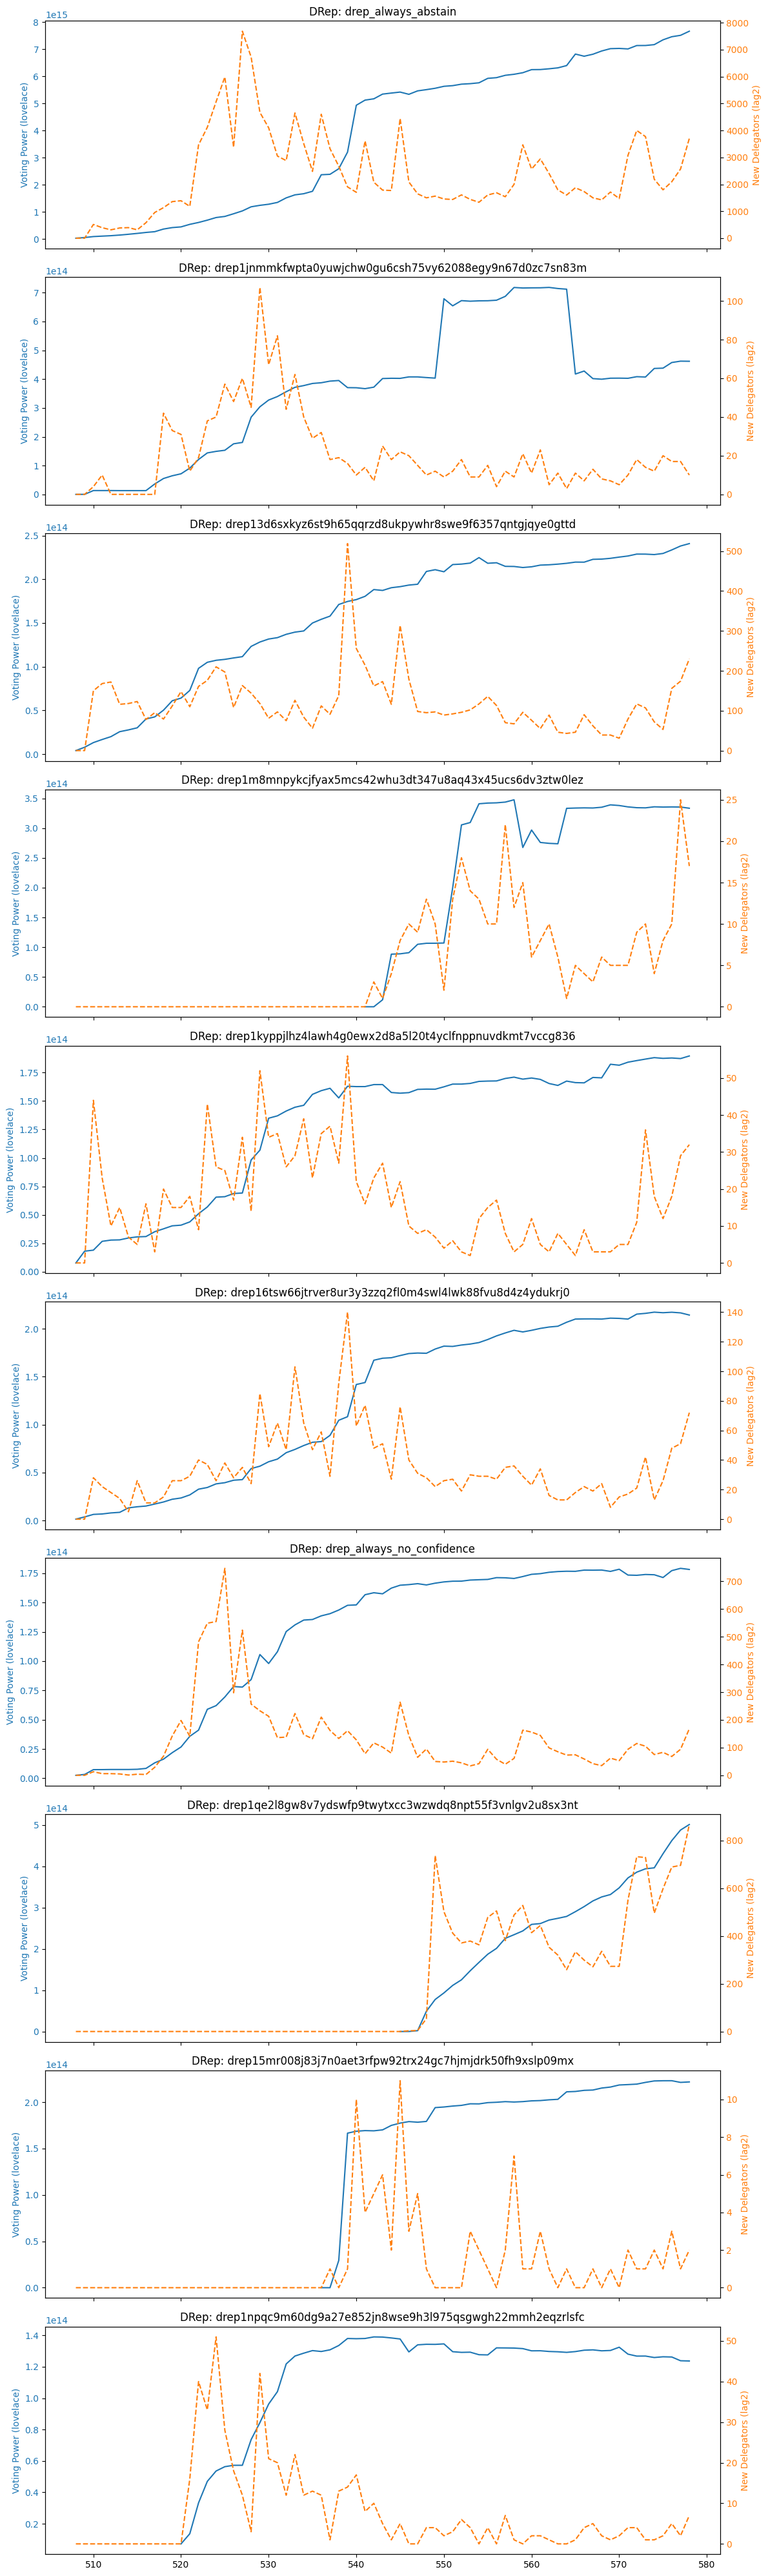

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your merged dataset
df = pd.read_csv("./data/drep_new_delegations_and_amount_per_epoch.csv")

# --- 1) Pick top 10 DReps by total voting power ---
top10_dreps = (
    df.groupby("drep_view")["voting_power_lovelace"]
      .sum()
      .nlargest(10)
      .index.tolist()
)

df_top = df[df["drep_view"].isin(top10_dreps)]

# --- 2) Plot each DRep in its own subplot ---
fig, axes = plt.subplots(10, 1, figsize=(12, 40), sharex=True)

for i, drep in enumerate(top10_dreps):
    sub = df_top[df_top["drep_view"] == drep]

    ax = axes[i]
    ax2 = ax.twinx()

    # Voting power (blue line, left axis)
    ax.plot(
        sub["epoch_no"], sub["voting_power_lovelace"],
        color="tab:blue", label="Voting Power"
    )
    ax.set_ylabel("Voting Power (lovelace)", color="tab:blue")
    ax.tick_params(axis="y", labelcolor="tab:blue")

    # New delegators lag2 (orange dashed line, right axis)
    ax2.plot(
        sub["epoch_no"], sub["new_delegators_lag2"],
        color="tab:orange", linestyle="--", label="New Delegators (lag2)"
    )
    ax2.set_ylabel("New Delegators (lag2)", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    ax.set_title(f"DRep: {drep}")

plt.xlabel("Epoch")
plt.tight_layout()
plt.show()
